In [1]:
%load_ext autoreload
%autoreload 2

### Pull Data

In [2]:
import os, json, sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.dirname(os.getcwd()))

from utils import DATA_DIR, ROOT_DIR
from utils.comet_utils import plot_all_metrics
from utils.comet_utils import fetch_experiments_by_run_name

with open(f'{ROOT_DIR}/.comet-api-key', 'r') as f: api_key = f.read().strip()

workspace = 'ai2'
project = 'peteish32'
run_name = 'peteish32'

if not os.path.exists(f'{DATA_DIR}/peteish32.json'):
    experiments = fetch_experiments_by_run_name(
        api_key=api_key,
        workspace=workspace,
        project_name=project,
        run_name=run_name
    )

    with open(f'{DATA_DIR}/peteish32.json', 'w') as f:
        json.dump(experiments, f, indent=2)

In [3]:
# Get combined results for all metrics
def process_experiment_file(experiments):
    metric_names = set()
    for exp in experiments:
        metric_names.update(exp['metrics'].keys())
    metric_names = list(metric_names)

    metric_data = {}
    for metric_name in sorted(metric_names):
        clean_name = metric_name.replace('eval/downstream/', '')\
                            .replace('/', '_')\
                            .replace(' ', '_')\
                            .lower()
        
        all_data = []
        for exp in experiments:
            if metric_name in exp['metrics']:
                df = pd.DataFrame({
                    'step': exp['step'][metric_name],
                    'value': exp['metrics'][metric_name]
                })
                all_data.append(df)
        
        if all_data:
            combined_df = pd.concat(all_data, ignore_index=True)
            metric_data[clean_name] = {
                'steps': combined_df['step'].tolist(),
                'values': combined_df['value'].tolist()
            }
    return metric_data

In [4]:
with open(f'{DATA_DIR}/peteish32.json', 'r') as f:
    experiments = json.load(f)

metric_data = process_experiment_file(experiments)

### Analysis

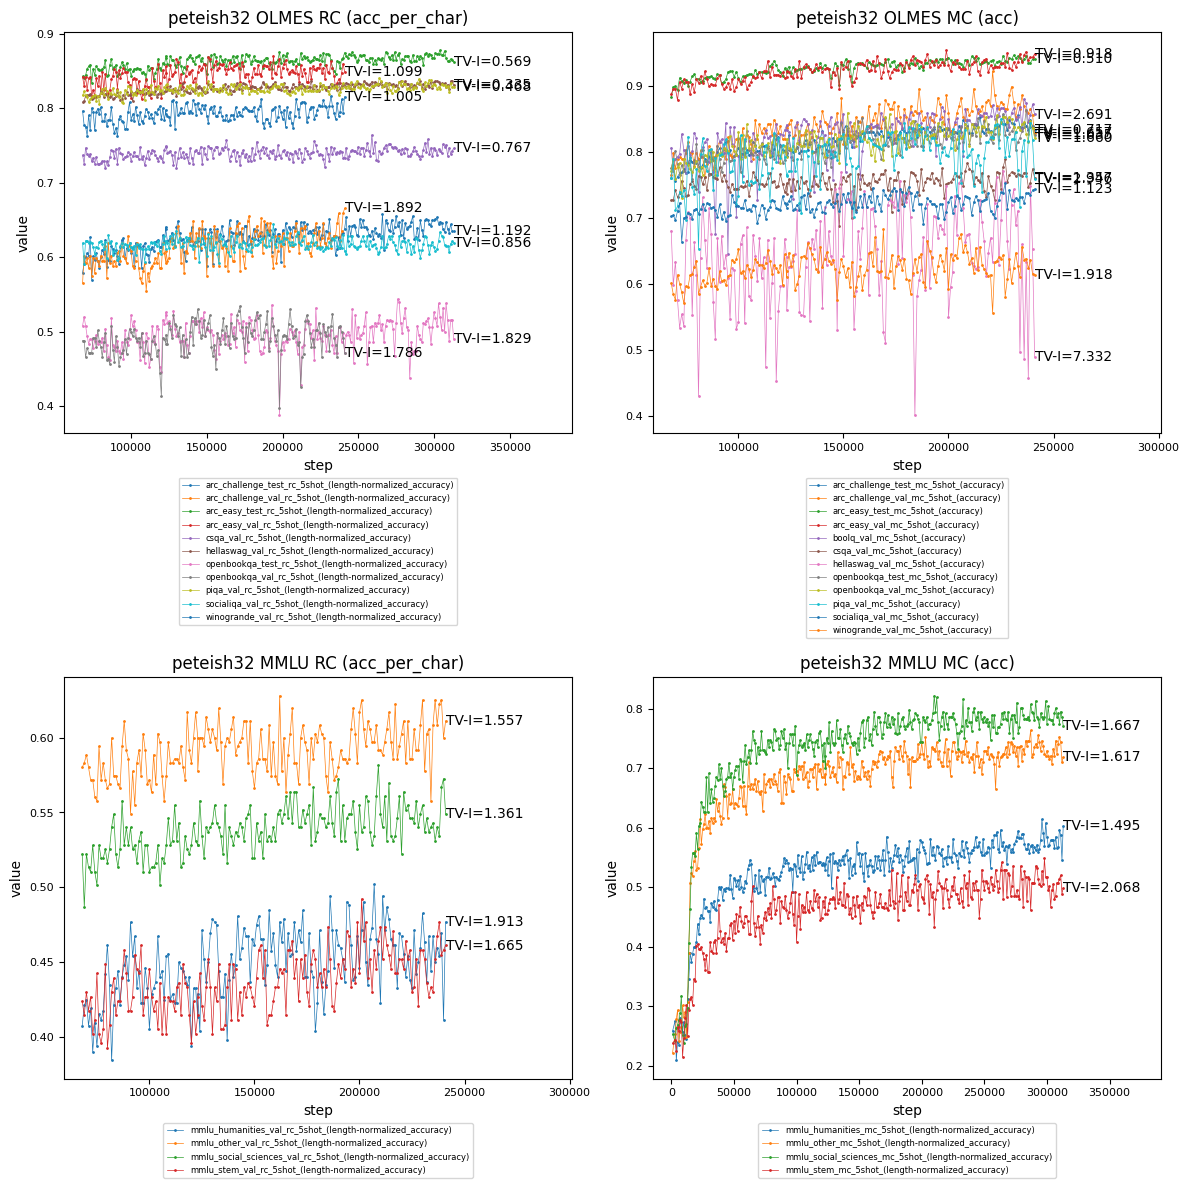

In [5]:
from plot import plot_training
from stats import calc_total_variation, calc_improvement, calculate_standard_error

N_COLS = 2
N_ROWS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 6*N_ROWS), squeeze=False)

def compute_total_variation(metric_data, metric, ax=None, color = None):
    step, acc = metric_data[metric]['steps'], metric_data[metric]['values']

    tv = calc_total_variation(acc, improvement=True) * 100
    filtered_acc = [a for s, a in zip(step, acc) if 100000 < s < 240000]
    improvement = calc_improvement(filtered_acc) * len(filtered_acc)

    if ax is not None:
        _ = plot_training(
            ax, 
            step, acc,
            xlabel='step', ylabel='value',
            label=metric,
            title='peteish32'
        )

        # Add total variation text
        text = ''
        text += f'\nTV-I={tv:.3f}'
        text = text.lstrip('\n')
        if text != '':
            ax.text(
                x=step[-1], y=acc[-1], s=text, color=(color[j] if color else None), 
                va='center', ha='left', zorder=5, fontsize=10
            )

            if metric != 'c4_loss' and metric != 'll_per_char':
                lines = ax.get_lines()
                max_x = max(max(line.get_xdata()) for line in lines)
                ax.set_xlim(right=max_x * 1.25)
        
        ax.legend(fontsize=6, loc='upper center', bbox_to_anchor=(0.5, -0.1))

    return tv, improvement

# Plot OLMES RC metrics (length-normalized accuracy)
ax = axes[0][0]
for metric_name, data in metric_data.items():
    if not all([
        'length-normalized_accuracy' in metric_name,
        'mc' not in metric_name,
        any(x in metric_name for x in ['_val_', '_test_']),
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES RC (acc_per_char)')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][1] 
for metric_name, data in metric_data.items():
    if not all([
        'accuracy' in metric_name,
        '_mc_' in metric_name,
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES MC (acc)')

# Plot MMLU RC metrics (length-normalized accuracy)
ax = axes[1][0]
for metric_name, data in metric_data.items():
    if not all([
        'length-normalized_accuracy' in metric_name,
        'mc' not in metric_name,
        'mmlu' in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 MMLU RC (acc_per_char)')

# Plot MMLU MC metrics (accuracy)
ax = axes[1][1]
for metric_name, data in metric_data.items():
    if not all([
        'accuracy' in metric_name,
        '_mc_' in metric_name, 
        'mmlu' in metric_name,
        '_val_' not in metric_name,
        'test' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 MMLU MC (acc)')

plt.tight_layout()

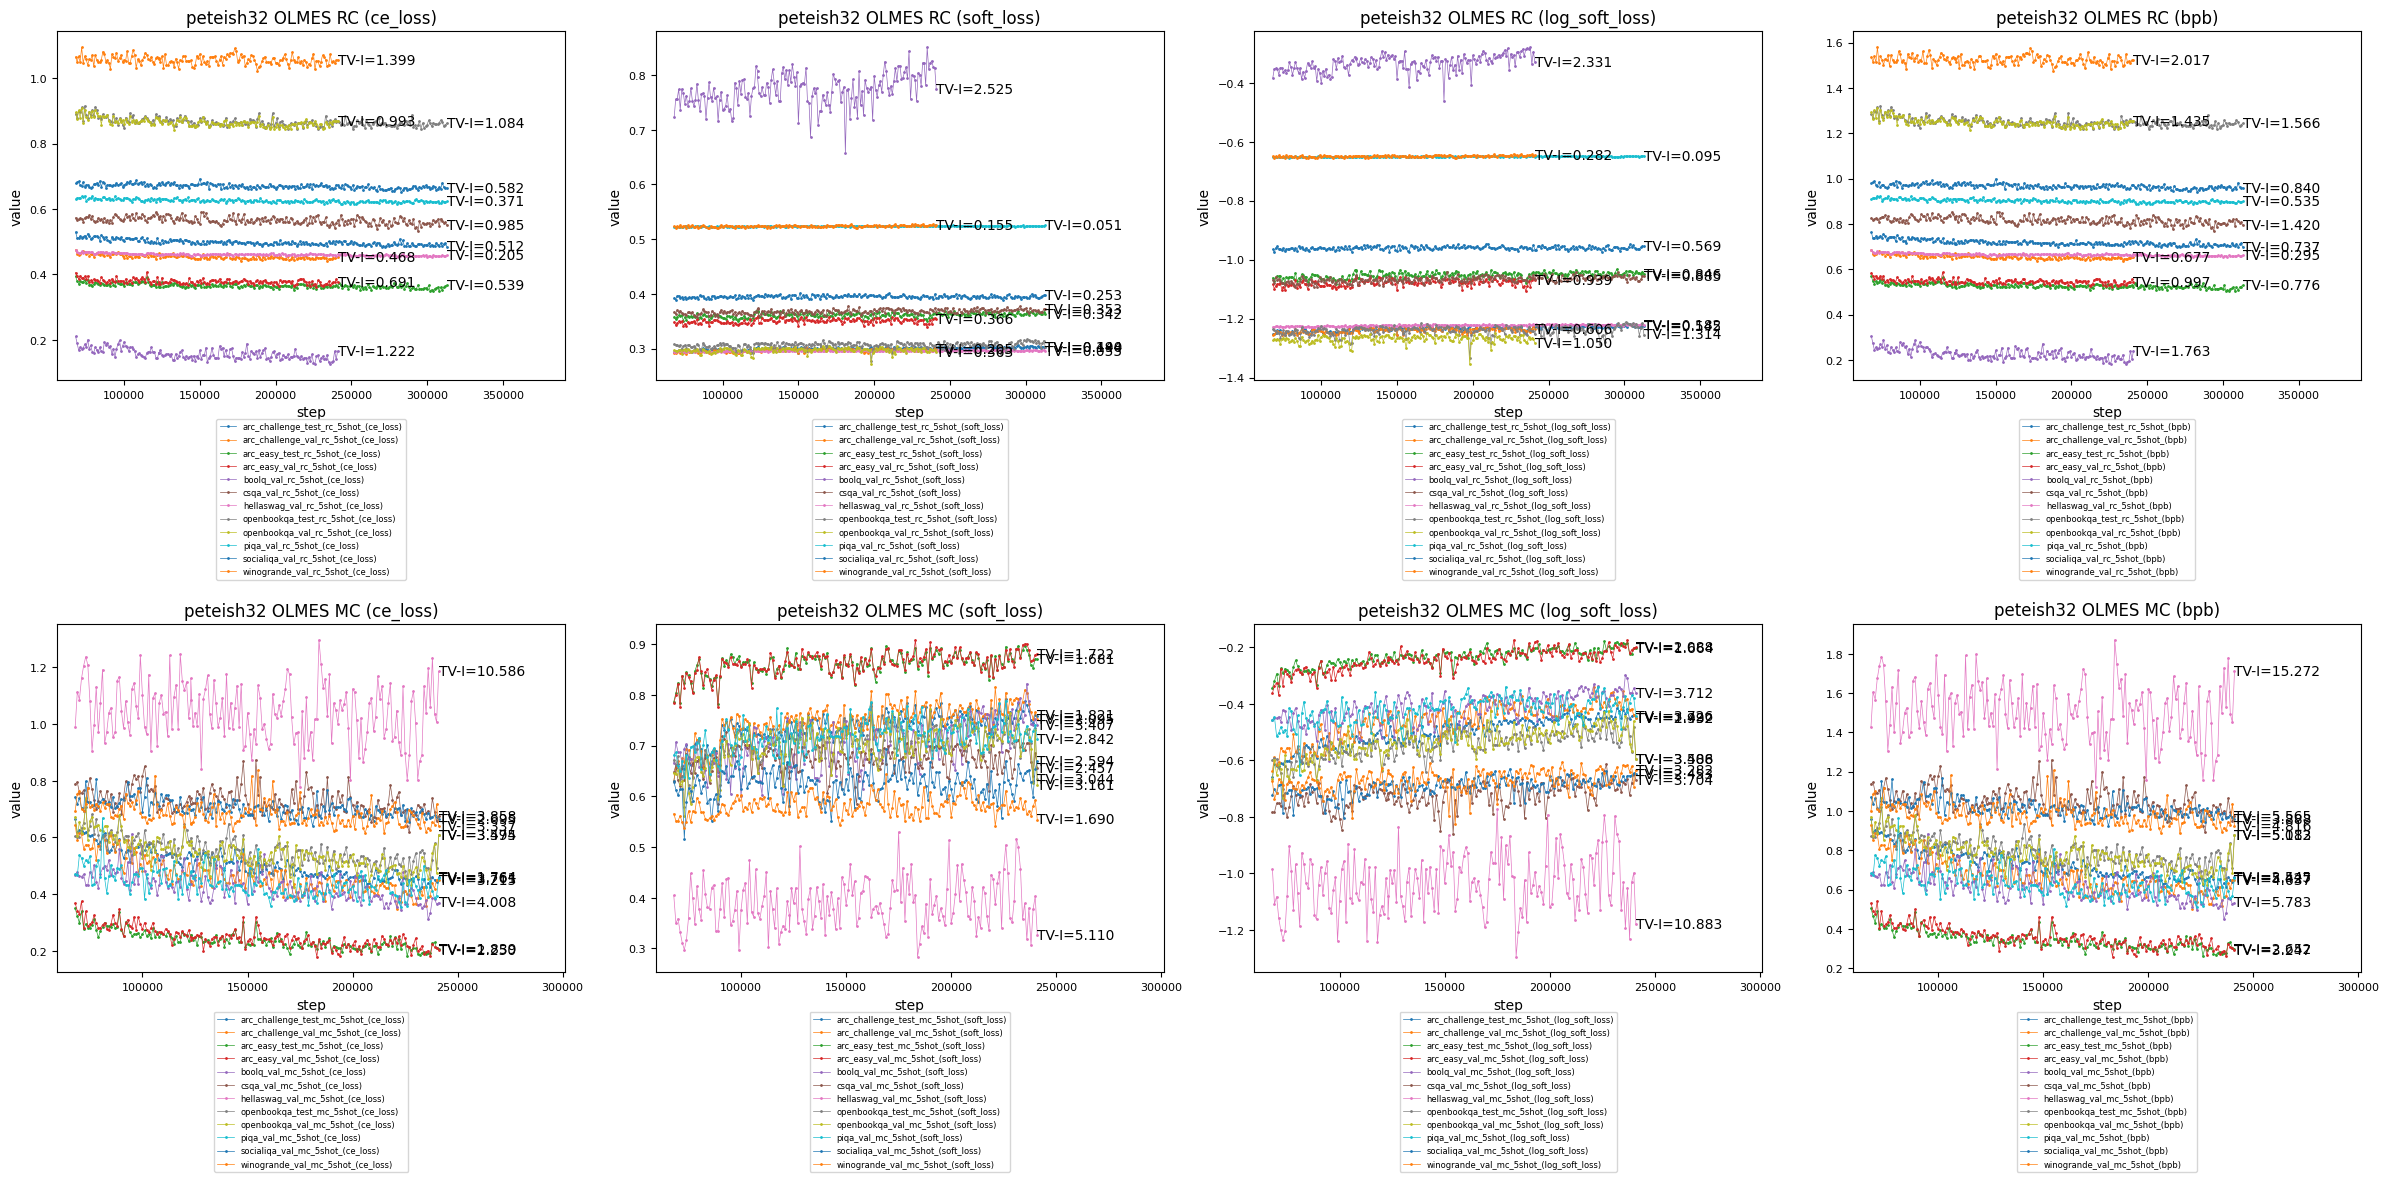

In [6]:
N_COLS = 4
N_ROWS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 6*N_ROWS), squeeze=False)

# Plot OLMES RC metrics (length-normalized accuracy)
ax = axes[0][0]
for metric_name, data in metric_data.items():
    if not all([
        'ce_loss' in metric_name,
        'mc' not in metric_name,
        any(x in metric_name for x in ['_val_', '_test_']),
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES RC (ce_loss)')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][1] 
for metric_name, data in metric_data.items():
    if not all([
        'soft_loss' in metric_name,
        'log_soft_loss' not in metric_name,
        'mc' not in metric_name,
        any(x in metric_name for x in ['_val_', '_test_']),
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES RC (soft_loss)')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][2] 
for metric_name, data in metric_data.items():
    if not all([
        'log_soft_loss' in metric_name,
        'mc' not in metric_name,
        any(x in metric_name for x in ['_val_', '_test_']),
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES RC (log_soft_loss)')

# Plot OLMES MC metrics (accuracy)
ax = axes[0][3] 
for metric_name, data in metric_data.items():
    if not all([
        'bpb' in metric_name,
        'mc' not in metric_name,
        any(x in metric_name for x in ['_val_', '_test_']),
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES RC (bpb)')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][0] 
for metric_name, data in metric_data.items():
    if not all([
        'ce_loss' in metric_name,
        '_mc_' in metric_name,
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES MC (ce_loss)')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][1] 
for metric_name, data in metric_data.items():
    if not all([
        'soft_loss' in metric_name,
        'log_soft_loss' not in metric_name,
        '_mc_' in metric_name,
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES MC (soft_loss)')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][2] 
for metric_name, data in metric_data.items():
    if not all([
        'log_soft_loss' in metric_name,
        '_mc_' in metric_name,
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES MC (log_soft_loss)')

# Plot OLMES MC metrics (accuracy)
ax = axes[1][3] 
for metric_name, data in metric_data.items():
    if not all([
        'bpb' in metric_name,
        '_mc_' in metric_name,
        'mmlu' not in metric_name,
        '5shot' in metric_name
    ]): continue
    compute_total_variation(metric_data, metric_name, ax=ax)
ax.set_title('peteish32 OLMES MC (bpb)')

plt.tight_layout()

In [7]:
from tqdm import tqdm

rows = []
cols = []
tv_vals = []
i_vals = []

for metric_name, data in metric_data.items():
    # Extract the value in parentheses and the part before it
    import re
    match = re.search(r'(.*?)\s*\((.*?)\)', metric_name)
    if match:
        row = match.group(1).strip()
        col = match.group(2).strip()
        tv, i = compute_total_variation(metric_data, metric_name)
        
        rows.append(row)
        cols.append(col)
        tv_vals.append(tv)
        i_vals.append(i)

def process_df(rows, cols, values):
    df = pd.DataFrame(index=pd.unique(rows), columns=pd.unique(cols))
    for row, col, val in zip(rows, cols, values):
        df.loc[row, col] = val

    df['accuracy'] = df['length-normalized_accuracy'].combine_first(df['accuracy'])
    df = df.drop('length-normalized_accuracy', axis=1)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Separate RC and MC
    df = df[df.index.str.contains('_rc_|_mc_', case=False)]
    df_rc = df[df.index.str.contains('_rc_', case=False)]
    df_mc = df[df.index.str.contains('_mc_', case=False)]
    df_rc.index = df_rc.index.str.replace('_rc_', '_', regex=False)
    df_mc.index = df_mc.index.str.replace('_mc_', '_', regex=False)
    df_rc = df_rc.add_suffix('_rc')
    df_mc = df_mc.add_suffix('_mc')

    # Combine DFs
    total_variation = pd.concat([df_rc, df_mc], axis=1)
    total_variation = total_variation.dropna(subset=['accuracy_mc'])
    total_variation.loc['avg'] = total_variation.mean(numeric_only=True)
    total_variation['avg'] = total_variation.mean(axis=1, numeric_only=True)

    # # Sort the rows and cols
    # total_variation = total_variation.sort_values('avg', ascending=False)
    # total_variation = total_variation.loc[:, total_variation.loc['avg'].sort_values(ascending=False).index]

    return total_variation

total_variation = process_df(rows, cols, tv_vals)
improvement = process_df(rows, cols, i_vals)

/var/folders/cr/z51hvhb932vbx29jw5hxd9nh0000gn/T/ipykernel_35875/1772108156.py:23: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  df = pd.DataFrame(index=pd.unique(rows), columns=pd.unique(cols))
/var/folders/cr/z51hvhb932vbx29jw5hxd9nh0000gn/T/ipykernel_35875/1772108156.py:23: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  df = pd.DataFrame(index=pd.unique(rows), columns=pd.unique(cols))


In [8]:
print(f'TV-I for all tasks and metrics:')
total_variation.round(3)

TV-I for all tasks and metrics:


,bpb_rc,ce_loss_rc,log_soft_loss_rc,soft_loss_rc,accuracy_rc,bpb_mc,ce_loss_mc,log_soft_loss_mc,soft_loss_mc,accuracy_mc,avg
arc_challenge_test_5shot_,0.737,0.512,0.545,0.190,1.192,2.545,1.764,1.492,1.821,0.717,1.151
arc_challenge_val_5shot_,0.677,0.468,0.606,0.205,1.892,4.637,3.215,2.932,2.095,1.657,1.838
arc_easy_test_5shot_,0.776,0.539,0.846,0.342,0.569,2.652,1.839,1.664,1.681,0.510,1.142
arc_easy_val_5shot_,0.997,0.691,0.939,0.366,1.099,3.247,2.250,2.088,1.722,0.918,1.432
boolq_val_5shot_,1.763,1.222,2.331,2.525,0.998,5.783,4.008,3.712,3.407,2.691,2.844
csqa_val_5shot_,1.420,0.985,0.885,0.353,0.767,5.565,3.858,3.704,2.457,1.357,2.135
hellaswag_val_5shot_,0.295,0.205,0.182,0.055,0.335,15.272,10.586,10.883,5.110,7.332,5.025
mmlu_humanities_val_5shot_,0.626,0.437,0.315,0.088,1.913,3.452,2.391,2.284,1.367,1.902,1.478
mmlu_other_val_5shot_,1.055,0.733,0.536,0.184,1.557,3.254,2.253,2.110,1.761,1.551,1.500
mmlu_social_sciences_val_5shot_,0.632,0.439,0.385,0.120,1.361,3.870,2.682,2.541,2.015,1.600,1.564


In [9]:
print(f'Improvement for all tasks and metrics (for 100_000 < step < 240_000):')
(improvement*100).round(3)

Improvement for all tasks and metrics (for 100_000 < step < 240_000):


,bpb_rc,ce_loss_rc,log_soft_loss_rc,soft_loss_rc,accuracy_rc,bpb_mc,ce_loss_mc,log_soft_loss_mc,soft_loss_mc,accuracy_mc,avg
arc_challenge_test_5shot_,-2.366,-1.635,1.357,0.470,1.792,-14.989,-10.382,10.757,1.070,5.205,-0.872
arc_challenge_val_5shot_,-1.581,-1.102,1.032,0.325,4.682,-17.189,-11.922,12.254,1.835,7.023,-0.464
arc_easy_test_5shot_,-1.714,-1.189,1.942,0.739,1.641,-6.150,-4.264,4.461,-1.084,2.904,-0.271
arc_easy_val_5shot_,-1.574,-1.092,1.914,0.731,0.877,-12.554,-8.701,8.809,0.667,4.035,-0.689
boolq_val_5shot_,-2.055,-1.426,2.369,7.606,0.367,-13.993,-9.699,10.674,8.364,6.300,0.851
csqa_val_5shot_,-5.930,-4.112,0.165,-0.090,0.573,-23.114,-16.019,16.544,-6.893,0.491,-3.838
hellaswag_val_5shot_,-1.064,-0.737,1.023,0.301,2.101,6.642,4.605,-4.569,-3.797,8.753,1.326
mmlu_humanities_val_5shot_,-2.114,-1.448,0.664,0.235,4.054,-1.957,-1.377,2.694,-1.056,-0.386,-0.069
mmlu_other_val_5shot_,-4.941,-3.424,2.015,0.678,6.197,-6.361,-4.420,5.489,0.022,4.507,-0.024
mmlu_social_sciences_val_5shot_,-3.228,-2.239,1.280,0.301,5.341,-12.543,-8.699,9.341,2.228,6.231,-0.199


In [10]:
# Calculate TV-I on each metric
    # Compute average TV-I on each setup (accuracy vs. BPB vs. CE Loss, etc.)

# Calculate improvement slope after some number of training steps (seperate RC and MC)

# (maybe) try that metric that was fitted to the log curve

# (maybe) try to predict performance